In [ ]:
# from google.colab import drive
import pandas as pd
import os

# drive.mount("/content/drive")

# df = pd.read_csv('/content/drive/MyDrive/Datasets/spam_data.csv')
df = pd.read_csv("../data/spam_data.csv")
print(df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     word_free  word_money  word_winner  word_click  word_urgent  \
0     0.116603    0.081405     0.248621    0.107026     0.084280   
1     0.150017    0.202468     0.071720    0.227412     0.228002   
2     0.009429    0.190923     0.094307    0.152571     0.272270   
3     0.085727    0.129830     0.205633    0.099737     0.016976   
4     0.050113    0.050286     0.011001    0.220921     0.199141   
..         ...         ...          ...         ...          ...   
995   0.094830    0.016722     0.182944    0.072241     0.116042   
996   0.238872    0.081584     0.207708    0.079219     0.281721   
997   0.529614    0.466077     1.098918    0.619738     1.067250   
998   0.081242    0.074268     0.018758    0.137682     0.219820   
999   0.274527    0.159909     0.047386    0.208770     0.237978   

     num_exclamation  num_dollar  num_capitals  email_

In [ ]:
df.isna().sum()

,0
word_free,0
word_money,0
word_winner,0
word_click,0
word_urgent,0
num_exclamation,0
num_dollar,0
num_capitals,0
email_length,0
has_link,0


In [ ]:
X = df.drop('is_spam', axis=1)
Y = df['is_spam']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=1)

# Naive Bayes Model

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [ ]:
nb_preds = nb_model.predict(X_test)

[[177   0]
 [  0 123]]


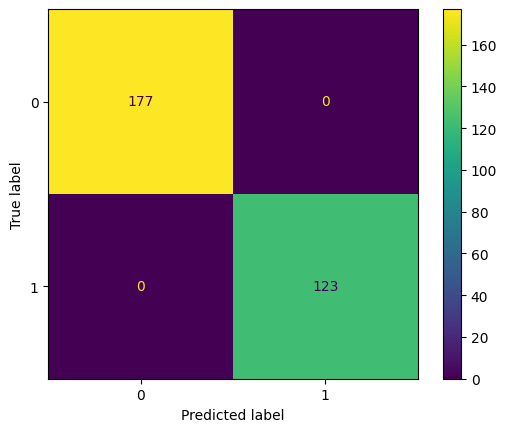

In [ ]:
cm = confusion_matrix(y_test, nb_preds, labels=[0, 1])
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()

# KNN Model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
n = len(df)
k = np.sqrt(n)
k

np.float64(31.622776601683793)

In [ ]:
k = 31
knn_class = KNeighborsClassifier(n_neighbors=k, metric='cosine')
knn_class.fit(X_train, y_train)

KNeighborsClassifier(metric='cosine', n_neighbors=31)

In [ ]:
knn_preds = knn_class.predict(X_test)

[[177   0]
 [  1 122]]


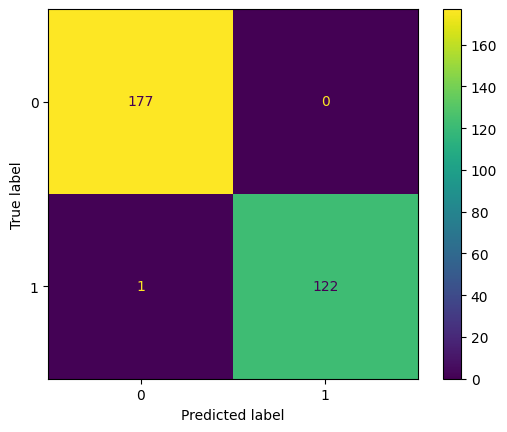

In [ ]:
cm = confusion_matrix(y_test, knn_preds, labels=[0, 1])
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()

# SVC Model

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
polykernel_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1, gamma="scale"))
])

polykernel_svc.fit(X_train, y_train)
svc_preds = polykernel_svc.predict(X_test)

[[177   0]
 [  0 123]]


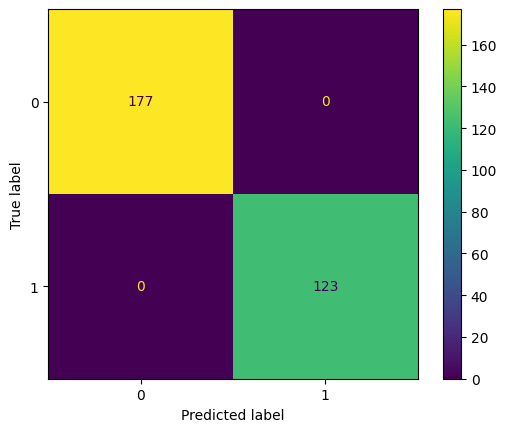

In [ ]:
cm = confusion_matrix(y_test, svc_preds, labels=[0, 1])
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()

# Compare Models  
Due to data being very classifiable and having 100% accuracy, I'll use a 'worse' model from the KNN Model: Euclidean metric, for the sake of discussing metrics

[[173   4]
 [ 31  92]]


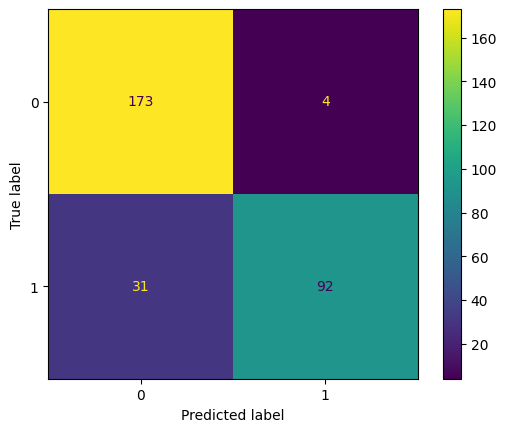

In [ ]:
k = 31
knn_class = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn_class.fit(X_train, y_train)
y_pred = knn_class.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()

**Accuracy**: "% of correct predictions"  
**Precision**: "% of positive predictions that were true positives"  
**Recall**: "% of true positives that were positive predictions"  
**F1-score**: harmonic mean of precision & recall  

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'] * 3,
    'Model': (['Naive Bayes'] * 4) + (['k-NN'] * 4) + (['SVM'] * 4),
    'Score': [
        # Naive Bayes scores
        accuracy_score(y_test, nb_preds), precision_score(y_test, nb_preds),
        recall_score(y_test, nb_preds), f1_score(y_test, nb_preds),
        # k-NN scores
        accuracy_score(y_test, knn_preds), precision_score(y_test, knn_preds),
        recall_score(y_test, knn_preds), f1_score(y_test, knn_preds),
        # SVM scores
        accuracy_score(y_test, svc_preds), precision_score(y_test, svc_preds),
        recall_score(y_test, svc_preds), f1_score(y_test, svc_preds)
    ]
}

# 2. Convert to a DataFrame
df_results = pd.DataFrame(data)

In [ ]:
df_results

,Metric,Model,Score
0,Accuracy,Naive Bayes,1.000000
1,Precision,Naive Bayes,1.000000
2,Recall,Naive Bayes,1.000000
3,F1-Score,Naive Bayes,1.000000
4,Accuracy,k-NN,0.996667
5,Precision,k-NN,1.000000
6,Recall,k-NN,0.991870
7,F1-Score,k-NN,0.995918
8,Accuracy,SVM,1.000000
9,Precision,SVM,1.000000


# Discussion Questions

Question 1:  
SVM and Naive Bayes performed better overall; albeit just by a little (due to KNN having 1 data point wrong). SVM is the most intuitive to understand why it works; because SVM works by having a straight line and margins as separator, it makes sense that it performs so well in a dataset in which the 2 classes are separated by straight boundaries. As for Naive Bayes, I would guess that it worked in a similar way with the probabilities, though it doesn't work intuitively visually like SVM does  

Question 2:  
Accuracy is the % of correct predictions, while precision penalizes you for making false positives. Precision is more important for spam decision; a poor/low precision score means you're making a lot of false positives. In terms of spam detection, you might wrongly flag an email as spam and thus hide it from the user, when in reality it was an important email. That'd be pretty bad  

Question 3:  
Naive Bayes is incredibly fast, so it can handle large, real-world datasets well. In a sense, it's an iterative process that can "train as it goes" or as it gets more data, and does not need large datasets to start with to be useful (though still able to scale well with increasing dataset sizes). It would also be most effective if we can assume feature independence.  

Question 4:  
Naive Bayes assumes that all features are independent of each other. In terms of spam detection, I would say this doesn't stand. The presence of the word "winner" and "money" could truly have a relationship (winners get rewards, rewards are usually money). I guess the model still performed well, however, since the datapoints are so uniform/cleanly separated.  

Question 5:  
I square-rooted _n_, which gave something about 31. 31 happened to already be prime, so I kept it.